In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

In [2]:
N_data = 100
N_mu = 100
mu = 1
sigma = 0.2

#definisco gli array 
data = np.array([])
sigma_gen = np.array([])
LH = np.array([])
distance = np.array([])

HOMOSCHEDASTIC CASE


In [3]:
#definisco la distribuzionee con parametri
distG = norm(loc=mu, scale=sigma)
a = np.linspace(-3 , 3 , 10000)

#genero i punti (HOMO)
data = np.random.normal(mu, sigma,N_data)
#for i in range (N_data):
#    sigma_gen = np.append(sigma_gen, sigma)
    
#genero i punti (ETERO)
sigma_gen = np.random.normal(0.2, 0.05,N_data)


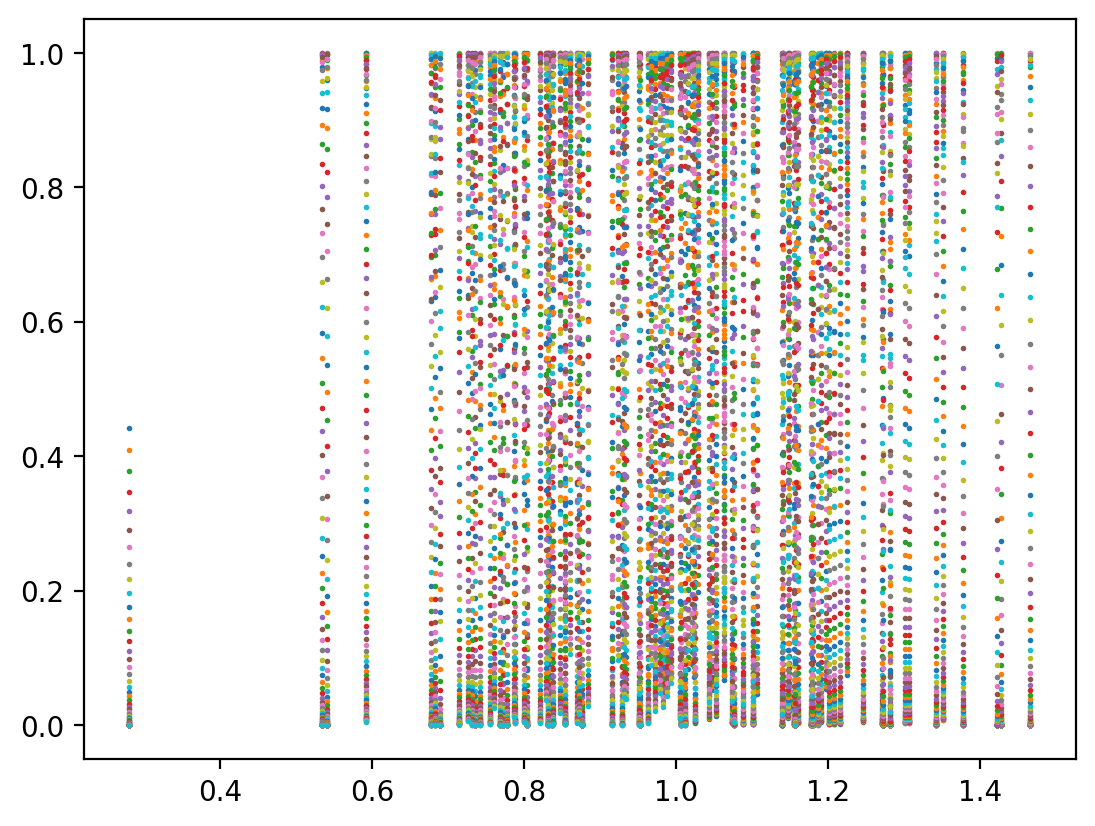

In [4]:


#calcolo likelyhood di {xi} (prodotto delle singole LH)
mu = np.linspace(0.5 , 1.5 , N_mu)
single_LH = np.ones((N_data,N_mu))

for j in range (N_mu):
    for i in range (N_data):
        single_LH[i][j] = np.exp((-((data[i] - mu[j])**2)/(2*sigma_gen[i]**2)))

tot_LH = np.array([])
for i in range(N_mu):
    tot_LH = np.append(tot_LH, np.prod(single_LH[:,i]))

for i in range (N_mu):
    plt.scatter(data, single_LH[:,i], s=1)
   
plt.show()


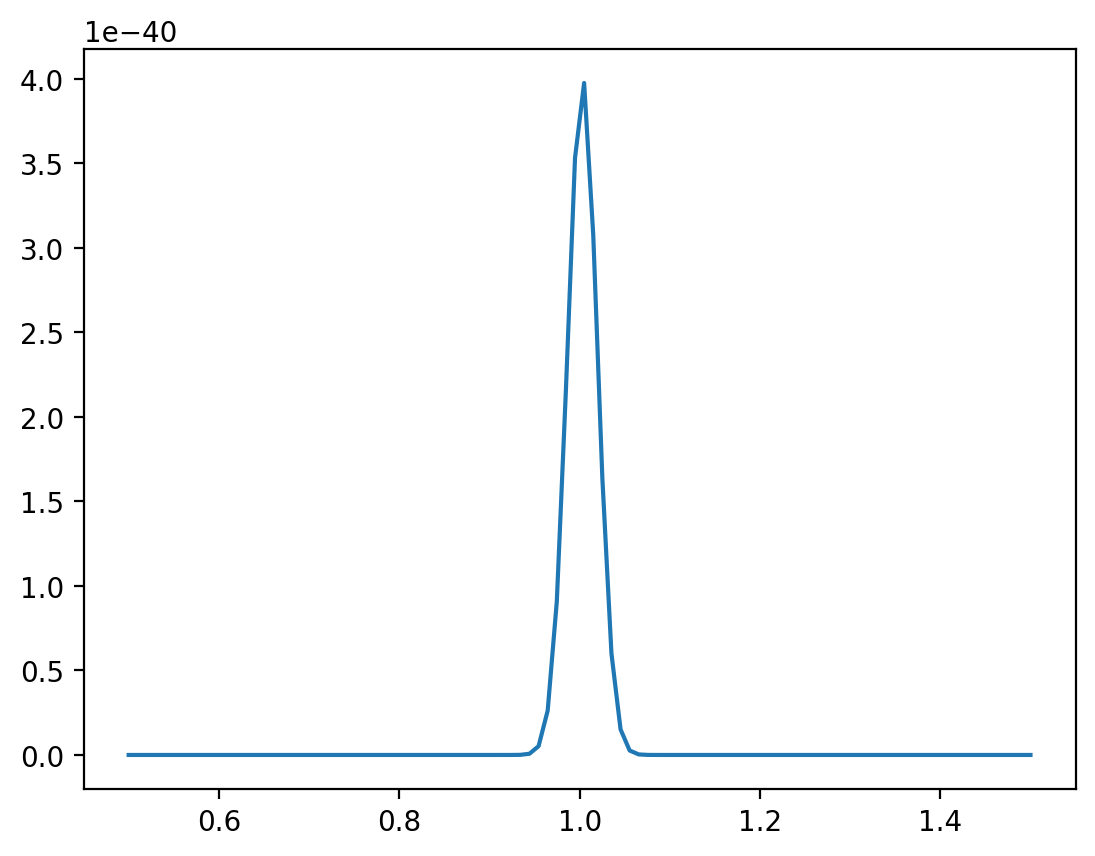

In [5]:
plt.plot(mu,tot_LH)
plt.show()

In [6]:
#trovo il massimo della likelyhood con argsort
MAX = np.where(tot_LH == np.ndarray.max(tot_LH))

#stampo mu che massimizza la likelyhood
mu[MAX[0][0]]

1.0050505050505052

In [7]:
#stampo la sigma che massimizza la likelyhood
sigma_gen[MAX[0][0]]

0.21982618276135962

PART 2 - Fisher matrix


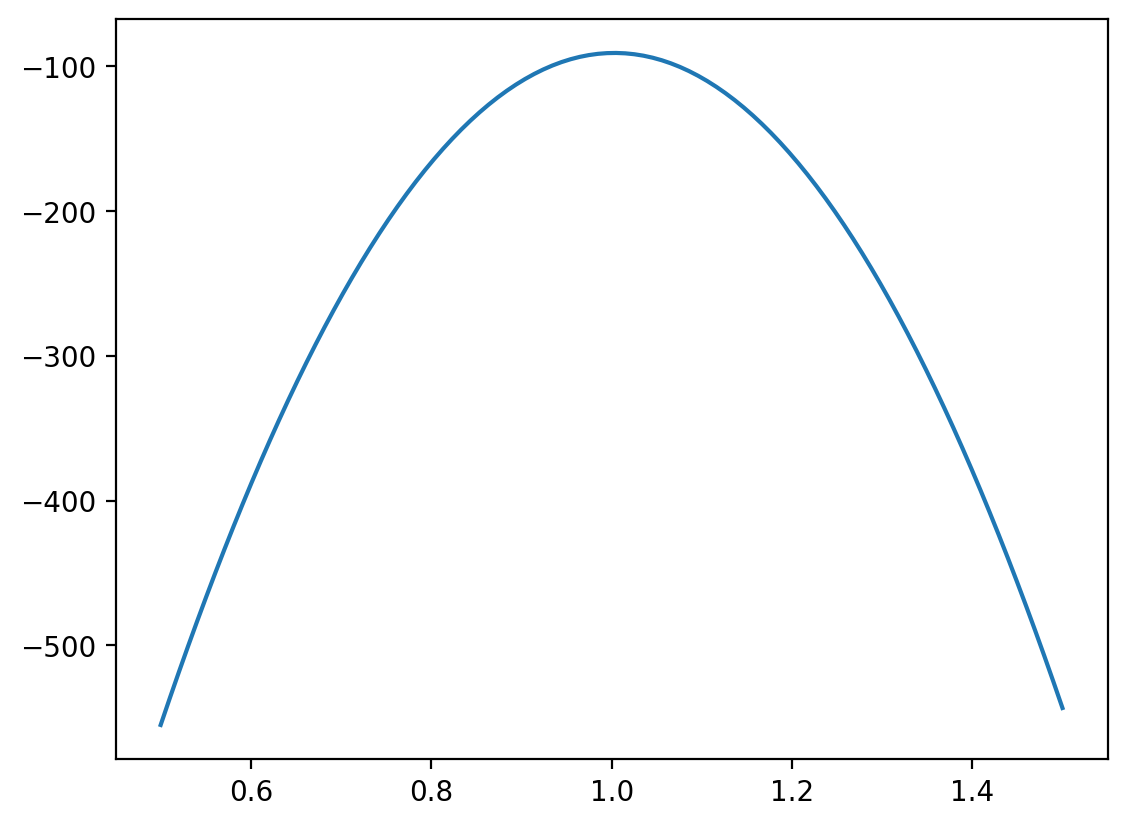

In [8]:
log_like = np.log(tot_LH + 10**(-300))
plt.plot(mu,log_like)
plt.show()

trovo la fisher matrix ricostruendo la derivata seconda con "np.diff"

In [9]:
delta_mu = (1.5 - 0.5) /N_mu
#derivata prima
log_like_second = np.diff(np.diff(log_like)) / ((delta_mu)**2)
error = (np.sqrt(-1*log_like_second))**(-1)
error[MAX[0][0]]

0.016346720724773424